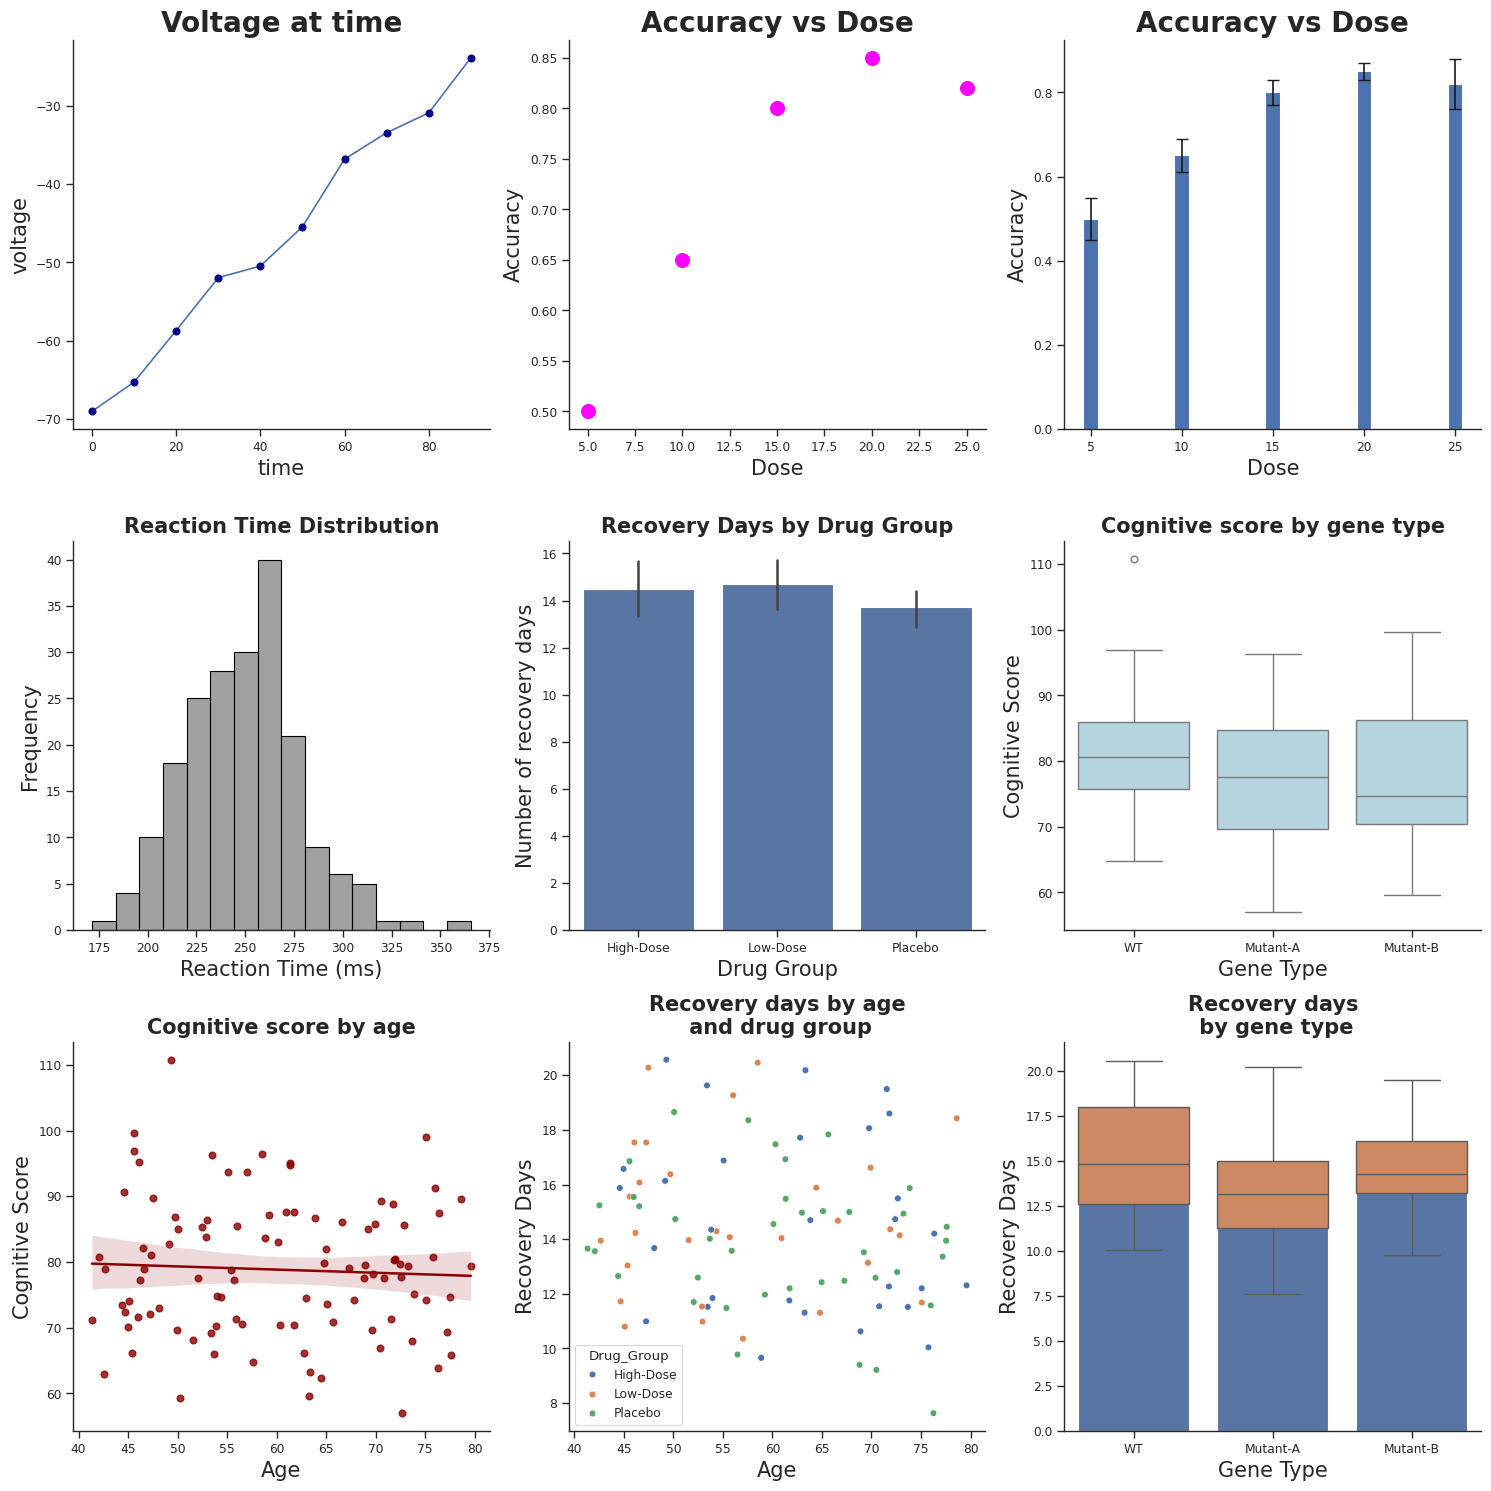

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", context="paper", font_scale=1.0)
np.random.seed(42)

# Raw Arrays
time = np.arange(0, 100, 10)
voltage = -70 + time * 0.5 + np.random.normal(0, 2, 10)
dose = np.array([5, 10, 15, 20, 25])
accuracy = np.array([0.5, 0.65, 0.8, 0.85, 0.82])
acc_error = np.array([0.05, 0.04, 0.03, 0.02, 0.06])
reaction_times = np.random.normal(250, 30, 200)

# Pandas DataFrame
df = pd.DataFrame({
    'Patient': range(1, 101),
    'Gene_Type': np.random.choice(['WT', 'Mutant-A', 'Mutant-B'], 100),
    'Drug_Group': np.random.choice(['Placebo', 'Low-Dose', 'High-Dose'], 100),
    'Recovery_Days': np.random.normal(14, 3, 100),
    'Cognitive_Score': np.random.normal(80, 10, 100),
    'Age': np.random.uniform(40, 80, 100)
})

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

#top left
axes[0,0].plot(time, voltage, marker="o", mfc="darkblue",
               mec="darkblue", linestyle="solid")
axes[0,0].set_title("Voltage at time", fontsize= 20, fontweight = "bold")
axes[0,0].set_xlabel("time", fontsize = 15)
axes[0,0].set_ylabel("voltage", fontsize=15)
sns.despine()

#top middle
axes[0,1].scatter(dose, accuracy, color="magenta", s = 100)
axes[0,1].set_title("Accuracy vs Dose", fontsize= 20, fontweight = "bold")
axes[0,1].set_xlabel("Dose", fontsize = 15)
axes[0,1].set_ylabel("Accuracy", fontsize=15)

#top right
axes[0,2].bar(dose, accuracy, yerr=acc_error, capsize=4)
axes[0,2].set_title("Accuracy vs Dose", fontsize= 20, fontweight = "bold")
axes[0,2].set_xlabel("Dose", fontsize = 15)
axes[0,2].set_ylabel("Accuracy", fontsize=15)

#middle left
sns.histplot(x=reaction_times, color="gray", edgecolor="black", ax=axes[1,0])
axes[1,0].set_title("Reaction Time Distribution", fontsize= 15, fontweight = "bold")
axes[1,0].set_xlabel("Reaction Time (ms)", fontsize = 15)
axes[1,0].set_ylabel("Frequency", fontsize = 15)

#middle
sns.barplot(data=df, x="Drug_Group", y="Recovery_Days", ax=axes[1,1])
axes[1,1].set_title("Recovery Days by Drug Group", fontsize= 15, fontweight = "bold")
axes[1,1].set_xlabel("Drug Group", fontsize = 15)
axes[1,1].set_ylabel("Number of recovery days", fontsize=15)

#middle right
sns.boxplot(data=df,x="Gene_Type", y="Cognitive_Score", color="lightblue", ax=axes[1,2])
axes[1,2].set_title("Cognitive score by gene type", fontsize=15, fontweight="bold")
axes[1,2].set_xlabel("Gene Type", fontsize=15)
axes[1,2].set_ylabel("Cognitive Score", fontsize=15)

#bottom left
sns.regplot(data=df, x="Age", y="Cognitive_Score", color="darkred",
            marker="o", ax=axes[2,0])
axes[2,0].set_title("Cognitive score by age", fontsize=15, fontweight="bold")
axes[2,0].set_xlabel("Age", fontsize=15)
axes[2,0].set_ylabel("Cognitive Score", fontsize=15)

#bottom middle
sns.scatterplot(data=df, x="Age", y="Recovery_Days", hue="Drug_Group", ax=axes[2,1])
axes[2,1].set_title("Recovery days by age\n and drug group", fontsize=15, fontweight="bold")
axes[2,1].set_xlabel("Age", fontsize=15)
axes[2,1].set_ylabel("Recovery Days", fontsize=15)

#bottom right
sns.barplot(data=df, x="Gene_Type", y="Recovery_Days", ax=axes[2,2])
sns.boxplot(data=df, x="Gene_Type", y="Recovery_Days", ax=axes[2,2])
axes[2,2].set_title("Recovery days\n by gene type", fontsize=15, fontweight="bold")
axes[2,2].set_xlabel("Gene Type", fontsize=15)
axes[2,2].set_ylabel("Recovery Days", fontsize=15)

plt.tight_layout()